# Introduction

Pycaret is an ope-source low-code machine learning library in Python that automates machine learning workflows.

## Time Series Module

Is now available in beta. It comes with a lot of functionalities, statistical testing, model training and selection, model analysis, automated hiperparameter tuning, experiment logging, deployment on cloud and more.

### Example Workflow

The workflow in Pycaret's time series module is really simple. Starts with the setup function where you define the forecast horizon **fh** and number of **folds**. You can also define the **fold_strategy** either **expanding** or **sliding**

After setup, **compare_models** train and evaluate 30+ algorithms from arima to xgboost.

**plot_model** function can be used before or after training. When used before training, it has a good collection of time series EDA plots using plotly interface. When used with a model, the **plot_model** works on model residuals and can be used to access model fit.

Finally the **predict_model** is used for generating forecasts

### Example that is not The coffee

In [ ]:
!pip install pycaret[full]

In [ ]:
import pycaret
print(pycaret. __version__)

2.3.5


In [ ]:
import pandas as pd
from pycaret.datasets import get_data

data = get_data("pycaret_downloads")
data["Date"] = pd.to_datetime(data["Date"])
data.head()


,Date,Total
0,7/8/2021,3773
1,7/9/2021,3172
2,7/10/2021,2079
3,7/11/2021,2725
4,7/12/2021,4542


,Date,Total
0,2021-07-08,3773
1,2021-07-09,3172
2,2021-07-10,2079
3,2021-07-11,2725
4,2021-07-12,4542


In [ ]:
data = data.groupby("Date").sum()
data = data.asfreq("D")
data.head()

,Total
Date,
2021-07-08,3773
2021-07-09,3172
2021-07-10,2079
2021-07-11,2725
2021-07-12,4542


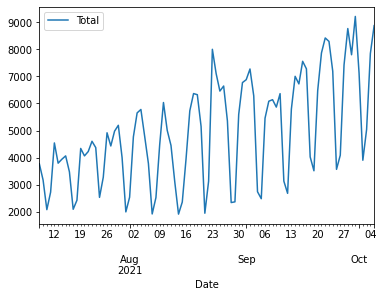

In [ ]:
data.plot()


This time series is the number of daily downloads of Pycaret

### Initialize Setup

In [ ]:
# with functional api
from pycaret.time_series import *
setup(data, fh = 7, fold = 3, session_id = 123)

# with new object-oriented API
from pycaret.internal.pycaret_experiment import TimeSeriesExperiment
exp = TimeSeriesExperiment()
exp.setup(data, fh = 7, fold = 3, session_id = 123) # session_id is similar to random_sample

ModuleNotFoundError: ignored

### Statistical Testing

In [ ]:
check_stats()

,Test,Test Name,Property,Setting,Value
0,Summary,Statistics,Length,,90.0
1,Summary,Statistics,Mean,,4960.366667
2,Summary,Statistics,Median,,4776.5
3,Summary,Statistics,Standard Deviation,,1939.000116
4,Summary,Statistics,Variance,,3759721.448315
5,Summary,Statistics,Kurtosis,,-0.920113
6,Summary,Statistics,Skewness,,0.22622
7,Summary,Statistics,# Distinct Values,,89.0
8,White Noise,Ljung-Box,Test Statictic,"{'alpha': 0.05, 'K': 24}",293.08932
9,White Noise,Ljung-Box,Test Statictic,"{'alpha': 0.05, 'K': 48}",460.125833


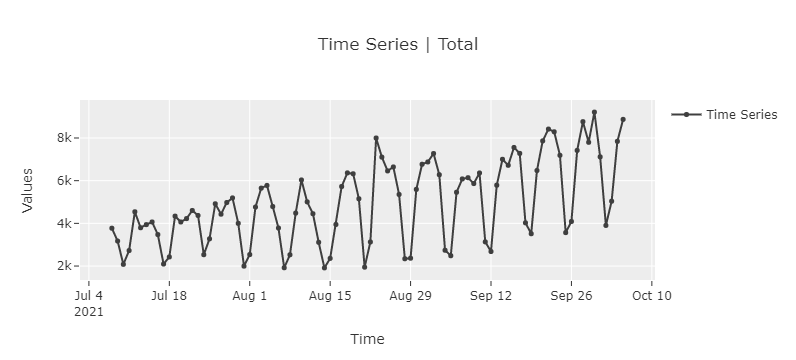

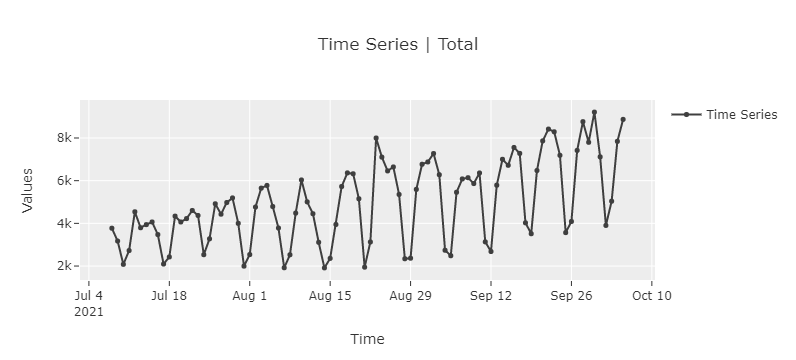

In [ ]:
# functional API
plot_model(plot = "ts")

# object-oriented API
exp.plot_model(plot = "ts")

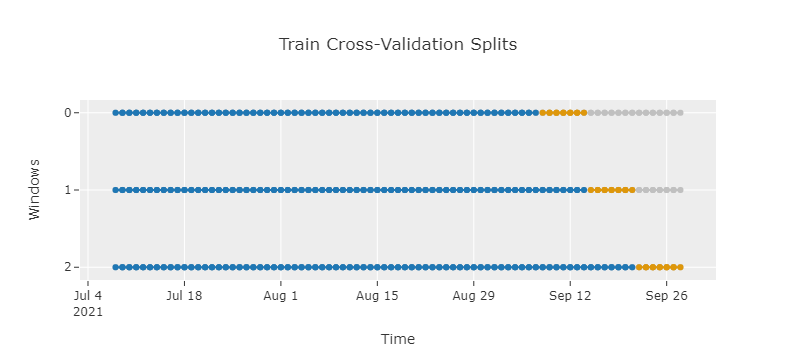

In [ ]:
# cross-validation plot
plot_model(plot = "cv")

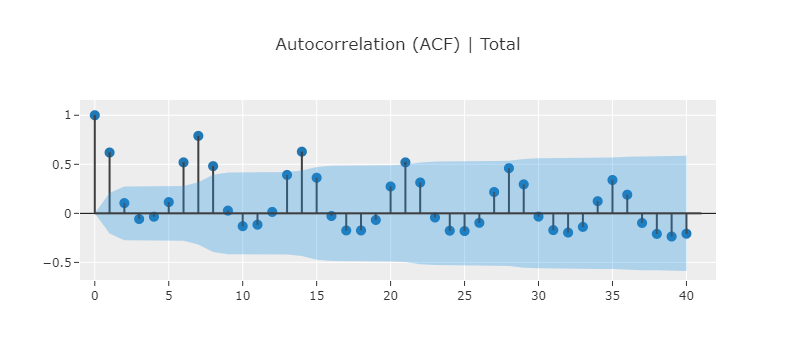

In [ ]:
# ACF Plot
plot_model(plot = "acf")

# NOTE: you can customize the plots with kwargs - e.g. number of lags, figure size (width, height), etc
# data_kwargs such as `nlags` are passed to the underlying functon that gets the ACF values
# figure kwargs such as `fig_size` & `fig_template` are passed to plotly and can have any value that plotly accepts
#exp.plot_model(plot="pacf", data_kwargs={'nlags':36, }, fig_kwargs={'fig_size': [800, 500], 'fig_template': 'simple_white'})

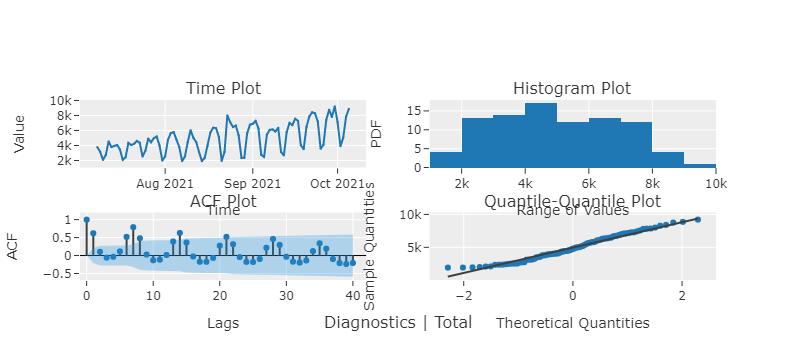

In [ ]:
# Diagnostics plot
plot_model(plot = "diagnostics")

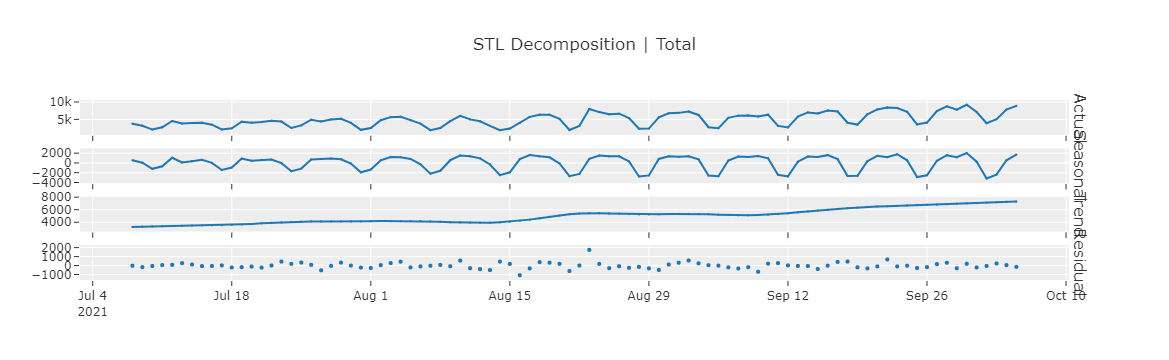

In [ ]:
# Decomposition plot
plot_model(plot = "decomp_stl")
#exp.plot_model(plot="decomp_classical")
#exp.plot_model(plot="decomp_classical", data_kwargs={'type': 'multiplicative'})
#exp.plot_model(plot="decomp_stl")


### training and selection of model

In [ ]:
# functional api
best = compare_models()

# object-oriented api

best = exp.compare_models()

,Model,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
auto_arima,Auto ARIMA,531.9174,626.2110,0.0911,0.0916,0.8632,1.7333
arima,ARIMA,568.4974,687.2509,0.0957,0.0975,0.8316,0.0200
theta,Theta Forecaster,526.3860,672.9424,0.0921,0.0988,0.8201,0.0100
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,607.7732,752.8756,0.0972,0.0995,0.8048,0.0100
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,607.7741,752.8753,0.0972,0.0995,0.8048,0.0133
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,607.7732,752.8756,0.0972,0.0995,0.8048,0.0167
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,607.7745,752.8751,0.0972,0.0995,0.8048,0.0167
lar_cds_dt,Least Angular Regressor w/ Cond. Deseasonalize & Detrending,607.7732,752.8756,0.0972,0.0995,0.8048,0.0167
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,605.3032,691.6546,0.0963,0.0998,0.8354,0.1667
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,622.3542,757.4090,0.1005,0.1026,0.8035,0.0133


In [ ]:
# Show the train-test splits on the dataset
# Internally split - len(fh) as test set, remaining used as test set
#exp.plot_model(plot="train_test_split")

# Show the Cross Validation splits inside the train set
#exp.plot_model(plot="cv")

In [ ]:
# create fbprophet model
auto_arima = create_model('auto_arima')
print(auto_arima)

,cutoff,MAE,RMSE,MAPE,SMAPE,R2
0,2021-09-07,460.6736,631.3084,0.0916,0.0853,0.8343
1,2021-09-14,531.2963,570.4029,0.0911,0.0961,0.8739
2,2021-09-21,603.7823,676.9218,0.0907,0.0935,0.8814
Mean,nan,531.9174,626.2110,0.0911,0.0916,0.8632
SD,nan,58.4255,43.6353,0.0004,0.0046,0.0206


AutoARIMA(D=None, alpha=0.05, d=None, error_action='warn',
          information_criterion='aic', max_D=1, max_P=2, max_Q=2, max_d=2,
          max_order=5, max_p=5, max_q=5, maxiter=50, method='lbfgs', n_fits=10,
          n_jobs=1, offset_test_args=None, out_of_sample_size=0, random=False,
          random_state=123, scoring='mse', scoring_args=None, seasonal=True,
          seasonal_test='ocsb', seasonal_test_args=None, sp=7, start_P=1,
          start_Q=1, start_p=2, start_params=None, ...)


In [ ]:
tuned_auto_arima = tune_model(auto_arima)
print(tuned_auto_arima)

,cutoff,MAE,RMSE,MAPE,SMAPE,R2
0,2021-09-07,460.6736,631.3084,0.0916,0.0853,0.8343
1,2021-09-14,531.2963,570.4029,0.0911,0.0961,0.8739
2,2021-09-21,603.7823,676.9218,0.0907,0.0935,0.8814
Mean,nan,531.9174,626.2110,0.0911,0.0916,0.8632
SD,nan,58.4255,43.6353,0.0004,0.0046,0.0206


AutoARIMA(D=None, alpha=0.05, d=None, error_action='warn',
          information_criterion='aic', max_D=1, max_P=2, max_Q=2, max_d=2,
          max_order=5, max_p=5, max_q=5, maxiter=50, method='lbfgs', n_fits=10,
          n_jobs=1, offset_test_args=None, out_of_sample_size=0, random=False,
          random_state=123, scoring='mse', scoring_args=None, seasonal=True,
          seasonal_test='ocsb', seasonal_test_args=None, sp=7, start_P=1,
          start_Q=1, start_p=2, start_params=None, ...)


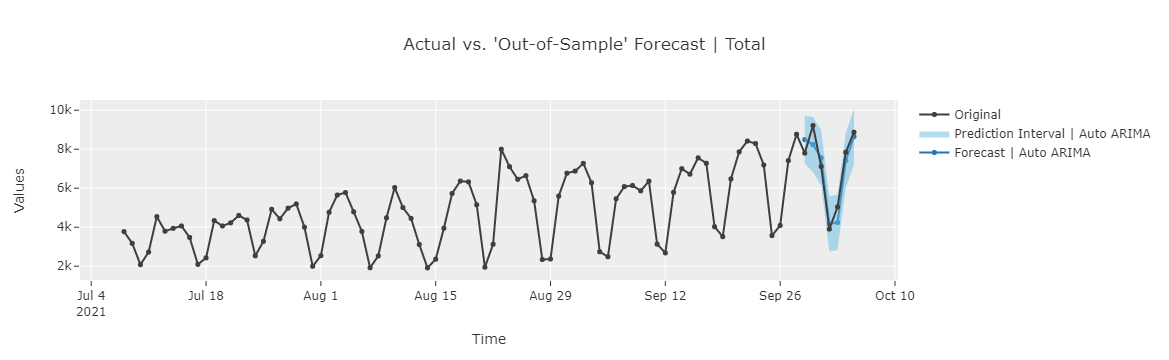

In [ ]:
plot_model(best, plot="forecast")

Forecast in unknown future

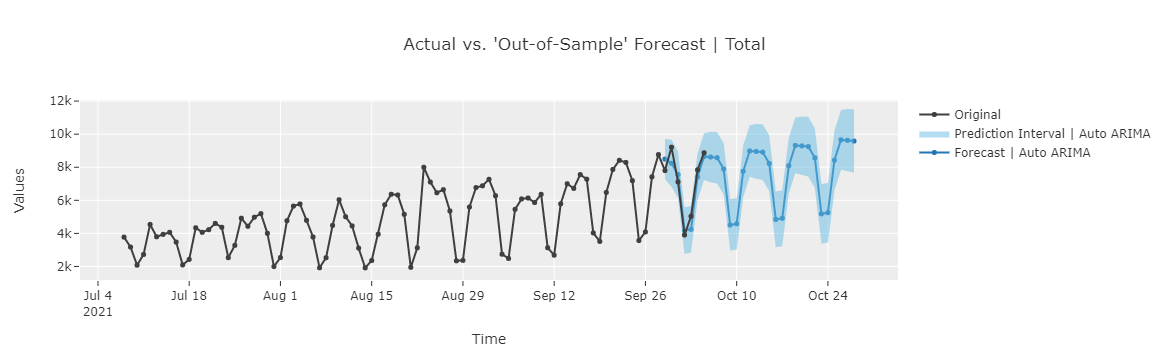

In [ ]:
plot_model(best, plot = "forecast", data_kwargs = {"fh":30})

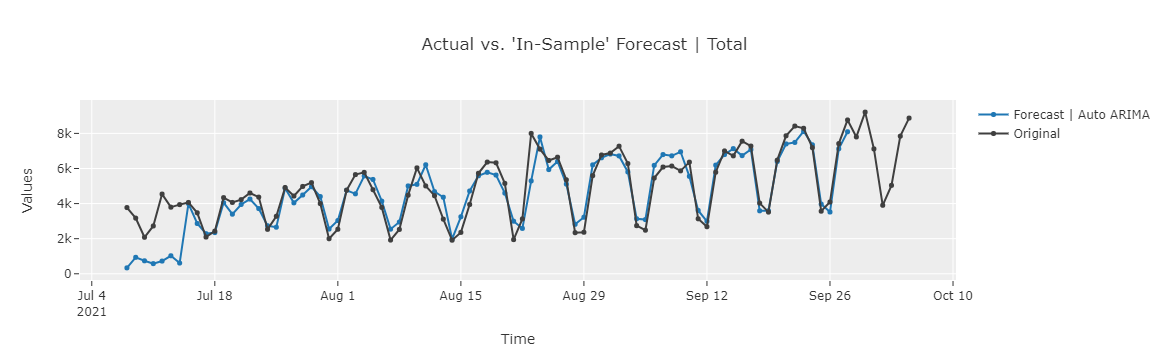

In [ ]:
# in sample plot
plot_model(best, plot = "insample")

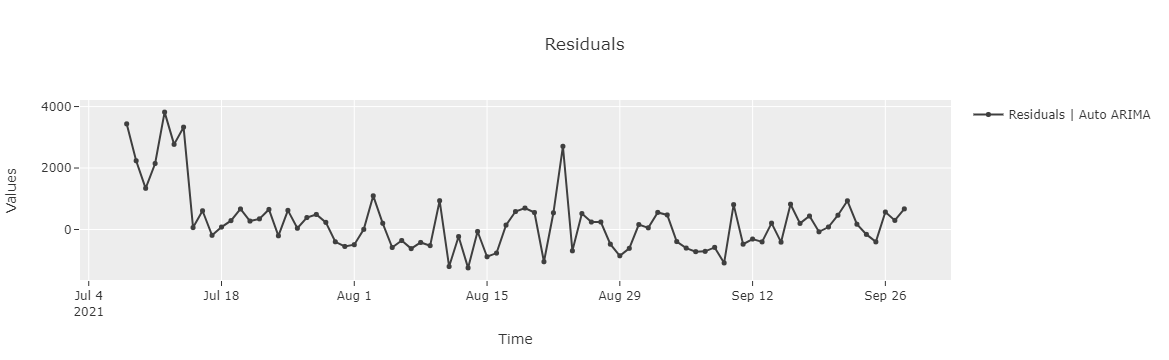

In [ ]:
# residuals plot
plot_model(best, plot = "residuals")

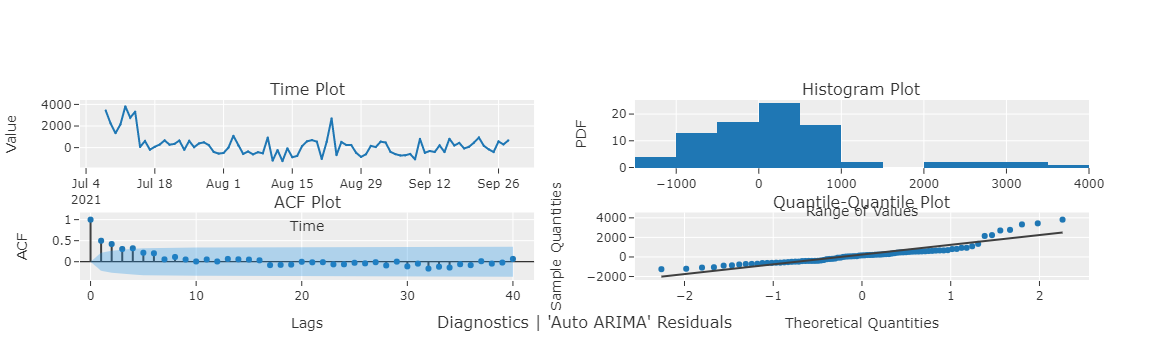

In [ ]:
# diagnostics plot
plot_model(best, plot = "diagnostics")

### Deployment

In [ ]:
# finalize model
final_best = finalize_model(best)

#generate predictions
predict_model(final_best, fh = 90)

2021-10-06     8392.9175
2021-10-07     9061.0281
2021-10-08     7701.1434
2021-10-09     4390.7520
2021-10-10     4972.7552
                 ...    
2021-12-30    13175.0763
2021-12-31    11815.1916
2022-01-01     8504.8002
2022-01-02     9086.8034
2022-01-03    12086.9193
Freq: D, Name: Total, Length: 90, dtype: float64

In [ ]:
# save the model
save_model(final_best, "my_best_model_example")

Transformation Pipeline and Model Successfully Saved


(AutoARIMA(D=None, alpha=0.05, d=None, error_action='warn',
           information_criterion='aic', max_D=1, max_P=2, max_Q=2, max_d=2,
           max_order=5, max_p=5, max_q=5, maxiter=50, method='lbfgs', n_fits=10,
           n_jobs=1, offset_test_args=None, out_of_sample_size=0, random=False,
           random_state=123, scoring='mse', scoring_args=None, seasonal=True,
           seasonal_test='ocsb', seasonal_test_args=None, sp=7, start_P=1,
           start_Q=1, start_p=2, start_params=None, ...),
 'my_best_model_example.pkl')

# Example 2 - Using Regression

In [ ]:
# read csv file

import pandas as pd
data = pd.read_csv("C:/Users/Vaio/Desktop/DH/PROJETO_INTEGRADOR/archive/AirPassengers.csv")
data = data.rename(columns = {"Month":"Date", "#Passengers":"Passengers"})
data["Date"] = pd.to_datetime(data["Date"])
data.head()

,Date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


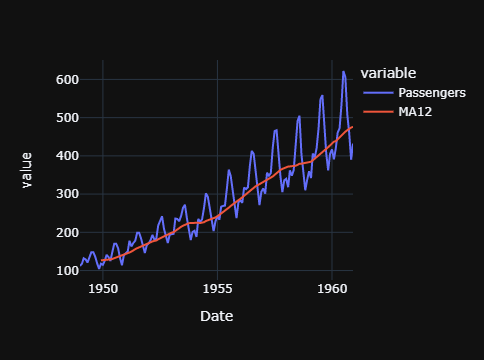

In [ ]:
# create 12 month moving average
data["MA12"] = data["Passengers"].rolling(12).mean()

# Plot the data and MA

import plotly.express as px
fig = px.line(data, x="Date", y=["Passengers", "MA12"], template = 'plotly_dark')
fig.show()

Since regression algorithms cannot directly deal with dates, let's extract some features from then and drop the original date column

In [ ]:
# extract month and year

data["Month"] = [i.month for i in data["Date"]]
data["Year"] = [i.year for i in data["Date"]]

# Create a sequence of numbers

data["Series"] = np.arange(1, len(data)+1)

# drop unnecessary columns and re-arrange
data.drop(["Date", "MA12"], axis = 1, inplace = True)
data = data[["Series", "Year", "Month", "Passengers"]]

# Check the dataset
data

,Series,Year,Month,Passengers
0,1,1949,1,112
1,2,1949,2,118
2,3,1949,3,132
3,4,1949,4,129
4,5,1949,5,121
...,...,...,...,...
139,140,1960,8,606
140,141,1960,9,508
141,142,1960,10,461
142,143,1960,11,390


In [ ]:
# split data into train test set
train = data[data["Year"]<1960]
test = data[data["Year"]>=1960]

# check shape
train.shape, test.shape

((132, 4), (12, 4))

One alternative way is pass the entire dataset to pycaret and let it handle the split then you have to pass **data_split_shuffle = False** in the setup function

### Now let's initialize the setup function

In [ ]:
# import the regression module

from pycaret.regression import *

# initialize setup

s = setup(data = train, test_data = test, target = "Passengers",
         fold_strategy="timeseries", numeric_features = ["Year", "Series"],
         fold = 3, transform_target = True, session_id = 123)

,Description,Value
0,session_id,123
1,Target,Passengers
2,Original Data,"(132, 4)"
3,Missing Values,False
4,Numeric Features,2
5,Categorical Features,1
6,Ordinal Features,False
7,High Cardinality Features,False
8,High Cardinality Method,None
9,Transformed Train Set,"(132, 13)"


In [ ]:
best = compare_models(sort = "MAE")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lar,Least Angle Regression,22.3980,923.8651,28.2855,0.5621,0.0878,0.0746,0.0100
lr,Linear Regression,22.3981,923.8749,28.2856,0.5621,0.0878,0.0746,1.5133
huber,Huber Regressor,22.4274,892.3078,27.9491,0.5981,0.0880,0.0749,0.0200
br,Bayesian Ridge,22.4783,932.2165,28.5483,0.5611,0.0884,0.0746,0.0100
ridge,Ridge Regression,23.1976,1003.9426,30.0410,0.5258,0.0933,0.0764,0.7900
lasso,Lasso Regression,38.4188,2413.5108,46.8468,0.0882,0.1473,0.1241,0.9933
en,Elastic Net,40.6486,2618.8761,49.4048,-0.0824,0.1563,0.1349,0.0100
omp,Orthogonal Matching Pursuit,44.3054,3048.2658,53.8613,-0.4499,0.1713,0.1520,0.0100
gbr,Gradient Boosting Regressor,50.1217,4032.0567,61.2306,-0.6189,0.2034,0.1538,0.0233
rf,Random Forest Regressor,52.3637,4647.0635,65.2883,-0.7726,0.2131,0.1578,0.0900


The best was LEAST ANGLE REGRESSION, lets check in the test set

In [ ]:
prediction_holdout = predict_model(best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Least Angle Regression,25.0714,972.2733,31.1813,0.8245,0.0692,0.0571


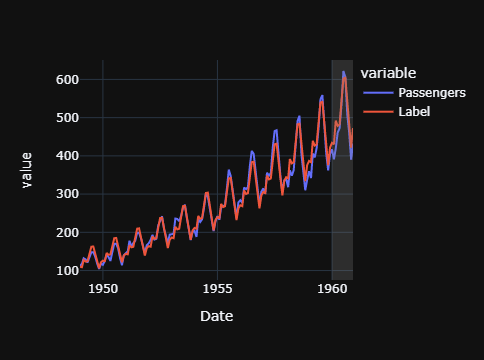

In [ ]:
# Lets plot the actual and predicted line to visualize the fit

# generate predictions on the original dataset
predictions = predict_model(best, data=data)
# add a date column in the dataset
predictions['Date'] = pd.date_range(start='1949-01-01', end = '1960-12-01', freq = 'MS')
# line plot
fig = px.line(predictions, x = "Date", y = ["Passengers", "Label"],
             template = "plotly_dark")
#add a vertical rectangle for test_separation
fig.add_vrect(x0 = "1960-01-01", x1 = "1960-12-01",
             fillcolor = "grey", opacity = 0.25,
             line_width = 0)
fig.show()

In [ ]:
final_best = finalize_model(best)

Now we have trained our model on entire dataset let's predict five year on future through 1964. First we need to create a dataset consisting of the month, year, series column


In [ ]:
future_dates = pd.date_range(start = "1961-01-01", end = "1965-01-01",
                            freq = "MS")

future_df = pd.DataFrame()

future_df["Month"] = [i.month for i in future_dates]
future_df["Year"] = [i.year for i in future_dates]
future_df["Series"] = np.arange(145, (145+len(future_dates)))

future_df.head()

,Month,Year,Series
0,1,1961,145
1,2,1961,146
2,3,1961,147
3,4,1961,148
4,5,1961,149


In [ ]:
predictions_future = predict_model(final_best, data = future_df)
predictions_future.head()

,Month,Year,Series,Label
0,1,1961,145,486.278268
1,2,1961,146,482.208187
2,3,1961,147,550.485967
3,4,1961,148,535.187177
4,5,1961,149,538.923789


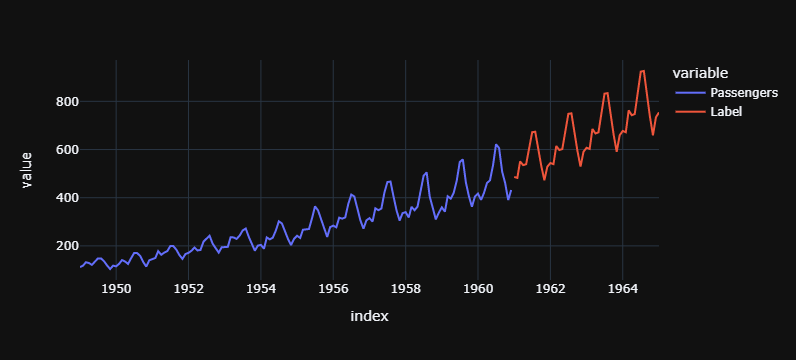

In [ ]:
concat_df = pd.concat([data,predictions_future], axis=0)
concat_df_i = pd.date_range(start='1949-01-01', end = '1965-01-01', freq = 'MS')
concat_df.set_index(concat_df_i, inplace=True)
fig = px.line(concat_df, x=concat_df.index, y=["Passengers", "Label"], template = 'plotly_dark')
fig.show()

# USING THE COFFE

Let's use the second example first because is easier and then use the first example code